# Analyze One-At-A-Time Ensembles

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib

import fates_calibration_library.analysis_functions as analysis
import fates_calibration_library.oaat_functions as oaat
import fates_calibration_library.plotting_functions as plotting
import fates_calibration_library.utils as utils
import fates_calibration_library.clm_functions as clm

In [2]:
import importlib

## Set Up
File locations and ensemble information

In [14]:
# parameter directory
param_dir = '/glade/work/afoster/FATES_calibration/parameter_files'

# history output directory
hist_dir = '/glade/work/afoster/FATES_calibration/history_files/compiled_files'

ensemble_dict = {
    'fates': {
        'param_list': os.path.join(param_dir, "param_list_sci.1.85.1_api.40.0.0.xls"),
        'key': os.path.join(param_dir, 'fates_oaat', 'fates_oaat_key.csv'),
        'name': 'fates_oaat',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'fates_oaat'),
        'param_prefix': 'FATES_OAAT_',
        'default_param': xr.open_dataset(os.path.join(param_dir,
                                                      'fates_params_default_sci.1.81.1_api.38.0.0_crops_vai.nc'))
    },
    'fates_clmpars': {
        'param_list': os.path.join(param_dir, 'CLM5_Parameter_List.csv'),
        'key': os.path.join(param_dir, 'clm6sp_oaat_key.csv'),
        'name': 'fates_oaat_clmpars',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'clm_oaat'),
        'param_prefix': 'CLM6SPoaat',
        'default_param': xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/paramdata/ctsm60_params.c241017.nc'),
        'nlmods_file': pd.read_csv(os.path.join(param_dir, 'clm6sp_nlmods.csv'))
    },
    'clm_btran': {
        'param_list': os.path.join(param_dir, 'CLM5_Parameter_List.csv'),
        'key': os.path.join(param_dir, 'clm6sp_oaat_key.csv'),
        'name': 'clm_oaat',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'clm_oaat'),
        'param_prefix': 'CLM6SPoaat',
        'default_param': xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/paramdata/ctsm60_params.c241017.nc'),
        'nlmods_file': pd.read_csv(os.path.join(param_dir, 'clm6sp_nlmods.csv'))
    }
}
fates = ensemble_dict['fates']
fates_clm = ensemble_dict['fates_clmpars']
clm_btran = ensemble_dict['clm_btran']

# config file with variable information in it
var_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/model_conversion.yaml'
var_dict = utils.get_config_file(var_config)

# output directory for figures
fig_dir = '/glade/work/afoster/FATES_calibration/figures/oaat_figs'

# variables to look at 
variables = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF', 'ASA', 'SOILWATER_10CM',
             'BTRANMN']

### History variables we want to analyze

## Read in parameter information

In [11]:
# oaat key
fates_key = pd.read_csv(fates['key'], index_col=0)

fates_param_dat = oaat.get_fates_param_dat(fates['param_list'], fates_key)

clm_param_dat = oaat.get_clm_param_dat(fates_clm['param_list'])

all_params = pd.concat([clm_param_dat.to_pandas().reset_index().drop(columns=['type', 'ensemble']).drop_duplicates(), 
                        fates_param_dat.to_pandas().reset_index().drop(columns=['type', 'ensemble']).drop_duplicates()])

In [15]:
fates_to_clm = {
    'not_vegetated': [0],
    'broadleaf_evergreen_tropical_tree': [4],
    'needleleaf_evergreen_extratrop_tree': [1, 2],
    'needleleaf_colddecid_extratrop_tree': [3],
    'broadleaf_evergreen_extratrop_tree': [5],
    'broadleaf_hydrodecid_tropical_tree': [6],
    'broadleaf_colddecid_extratrop_tree': [7, 8],
    'broadleaf_evergreen_extratrop_shrub': [9],
    'broadleaf_hydrodecid_extratrop_shrub': [],
    'broadleaf_colddecid_extratrop_shrub': [10],
    'broadleaf_evergreen_arctic_shrub': [],
    'broadleaf_colddecid_arctic_shrub': [11],
    'arctic_c3_grass': [12],
    'cool_c3_grass': [13],
    'c4_grass': [14],
    'c3_crop': [15],
    'c3_irrigated': [16]
}

# CLM PFT names by index
clm_index_to_name = {
    0: 'not_vegetated',
    1: 'needleleaf_evergreen_temperate_tree',
    2: 'needleleaf_evergreen_boreal_tree',
    3: 'needleleaf_deciduous_boreal_tree',
    4: 'broadleaf_evergreen_tropical_tree',
    5: 'broadleaf_evergreen_temperate_tree',
    6: 'broadleaf_deciduous_tropical_tree',
    7: 'broadleaf_deciduous_temperate_tree',
    8: 'broadleaf_deciduous_boreal_tree',
    9: 'broadleaf_evergreen_shrub',
    10: 'broadleaf_deciduous_temperate_shrub',
    11: 'broadleaf_deciduous_boreal_shrub',
    12: 'c3_arctic_grass',
    13: 'c3_non-arctic_grass',
    14: 'c4_grass',
    15: 'c3_crop',
    16: 'c3_irrigated'
}

def plot_pft_matrix():

    # Prepare matrix
    fates_labels = list(fates_to_clm.keys())
    clm_labels = [clm_index_to_name[i] for i in range(17)]
    
    matrix = pd.DataFrame(0, index=fates_labels, columns=clm_labels)
    
    # Fill the matrix with 1s where mappings exist
    for fates, clm_indices in fates_to_clm.items():
        for idx in clm_indices:
            clm_name = clm_index_to_name.get(idx, f"CLM_{idx}")
            matrix.loc[fates, clm_name] = 1
    
    # Plot heatmap
    plt.figure(figsize=(10, 9))
    sns.heatmap(matrix, cmap='Blues', cbar=False, linewidths=0.5, linecolor='lightgray', fmt='d')
    plt.xlabel("CLM PFTs")
    plt.ylabel("FATES PFTs")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
#plt.savefig(os.path.join(fig_dir, 'clm_fates_pfts.png'))

## Analysis

### Global annual means

In [16]:
# FATES SP ensemble with FATES parameters
fates_glob = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates['name']}_area_means.nc"),
                                       fates_param_dat, variables, fates['default'])
fates_mean = fates_glob.sel(summation_var='mean')

fates_biome = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates['name']}_biome_area_means.nc"),
                                       fates_param_dat, variables, fates['default'])

In [17]:
# FATES SP ensemble with CLM parameters
fatesclm_glob = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates_clm['name']}_area_means.nc"),
                                       clm_param_dat, variables, fates_clm['default'])
fatesclm_mean = fatesclm_glob.sel(summation_var='mean')

fatesclm_biome = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates_clm['name']}_biome_area_means.nc"),
                                       clm_param_dat, variables, fates_clm['default'])

In [18]:
# combine FATES ensembles into one
fates_glob_combo = oaat.get_combined(fates_glob, fatesclm_glob, 'fates parameters', 'clm parameters')
fates_combo_mean = fates_glob_combo.sel(summation_var='mean')

fates_biome_combo = oaat.get_combined(fates_biome, fatesclm_biome, 'fates parameters', 'clm parameters')

In [19]:
# CLM SP ensemble with CLM parameters (BTRAN)
clmbtran_glob = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{clm_btran['name']}_area_means.nc"),
                                       clm_param_dat, variables, clm_btran['default'])
clmbtran_glob['sim_source'] = 'clm parameters'
clmbtran_mean = clmbtran_glob.sel(summation_var='mean')

clm_biome = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{clm_btran['name']}_biome_area_means.nc"),
                                       clm_param_dat, variables, clm_btran['default'])

In [20]:
clm_ensemble = clmbtran_mean.where(clmbtran_mean.sum_diff > 0.0, drop=True)
clm_ensemble = clm_ensemble.to_pandas().reset_index().drop(columns=['ensemble'])
clm_ensemble['model'] = 'CLM'

fates_ensemble = fates_glob_combo.sel(summation_var='mean').where(fates_glob_combo.sum_diff > 0.0, drop=True)
fates_ensemble = fates_ensemble.to_pandas().reset_index().drop(columns=['ensemble'])
fates_ensemble['model'] = 'FATES'

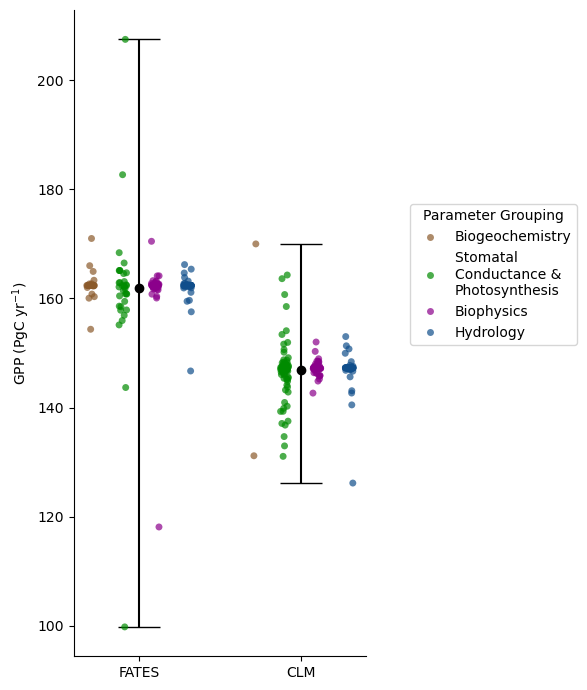

In [22]:
variable = 'GPP'
plotting.plot_ensemble_variance(fates_ensemble, clm_ensemble, 'FATES', 'CLM', variable,
                                var_dict[variable]['long_name'],
                               var_dict[variable]['global_units'])
plt.savefig(os.path.join(fig_dir, f'{variable}_ensemble_variance.png'))

In [23]:
# find non-zero parameters for all simulations
nonzero_params = oaat.get_params(fates_glob, fatesclm_glob, clmbtran_glob)
clm_params = np.unique(np.append(nonzero_params['fates_clm'], nonzero_params['clm_parameters']))

fates_nonzero = fates_param_dat.where(fates_param_dat.parameter_name.isin(nonzero_params['fates_only']), drop=True).to_pandas()
fates_nonzero['type'] = 'FATES'

clmfates_nonzero = clm_param_dat.where(clm_param_dat.parameter_name.isin(nonzero_params['fates_clm']), drop=True).to_pandas()
clmfates_nonzero['type'] = 'CLM'

clm_nonzero = clm_param_dat.where(clm_param_dat.parameter_name.isin(nonzero_params['clm_parameters']), drop=True).to_pandas()
clm_nonzero['type'] = 'CLM'

fates_oaat_params = pd.concat([fates_nonzero, clmfates_nonzero])

In [35]:
nonzero_params['fates_clm']

array(['a_coef', 'a_exp', 'accum_factor', 'aq_sp_yield_min',
       'baseflow_scalar', 'bsw_sf', 'ceta', 'csoilc', 'csol_clay',
       'csol_om', 'csol_sand', 'cv', 'd_max', 'drift_gs', 'e_ice',
       'eta0_vionnet', 'fff', 'frac_sat_soil_dsl_init', 'hksat_sf',
       'interception_fraction', 'lai_dl', 'liq_canopy_storage_scalar',
       'maximum_leaf_wetted_fraction', 'n_baseflow', 'n_melt_coef', 'pd',
       'perched_baseflow_scalar', 'rho_max', 'scvng_fct_mlt_sf',
       'snow_canopy_storage_scalar', 'snowcan_unload_temp_fact',
       'snowcan_unload_wind_fact', 'snw_rds_refrz', 'ssi', 'sucsat_sf',
       'tau_ref', 'tkd_clay', 'tkd_om', 'tkd_sand', 'tkm_om',
       'upplim_destruct_metamorph', 'watsat_sf', 'wimp', 'wind_min',
       'wind_snowcompact_fact', 'xdrdt', 'z_dl', 'zetamaxstable', 'zlnd',
       'zsno'], dtype=object)

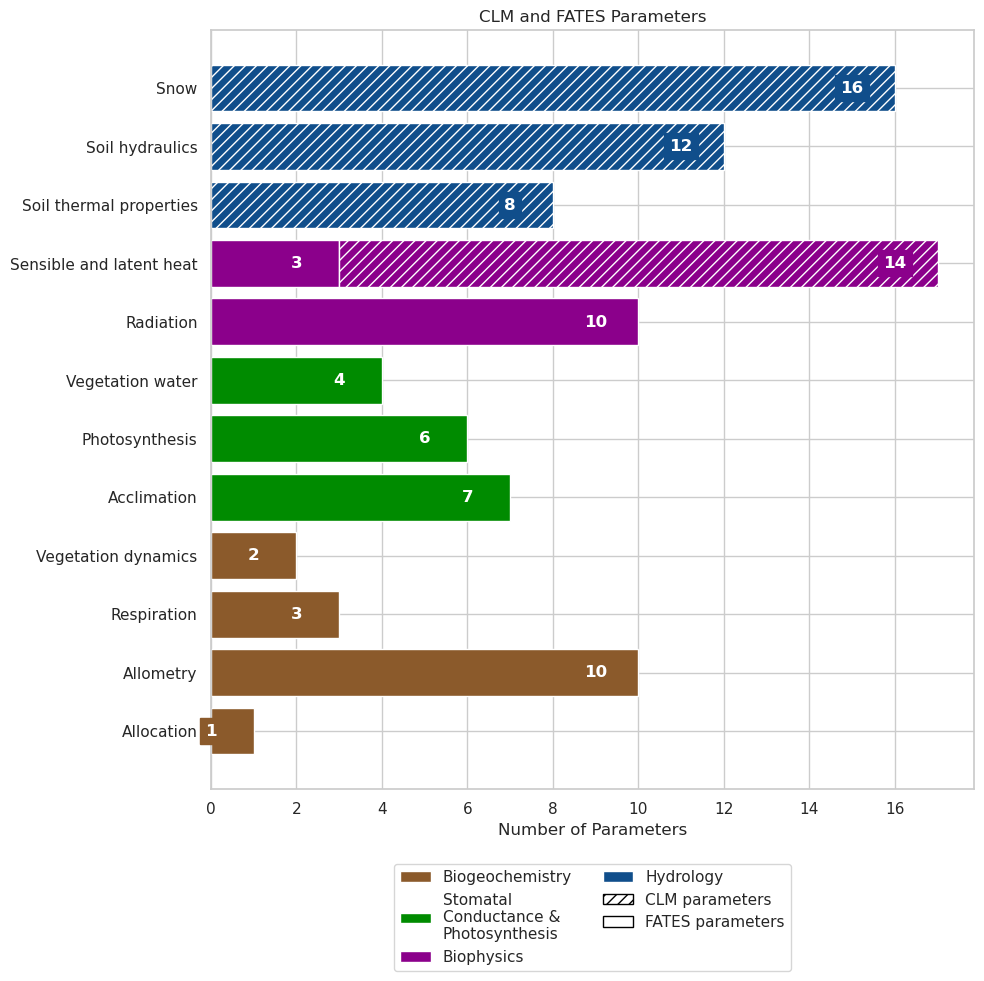

In [24]:
plotting.plot_oaat_params(fates_oaat_params.drop_duplicates(), 'CLM and FATES')
plt.savefig(os.path.join(fig_dir, 'fates_parameters.png'))

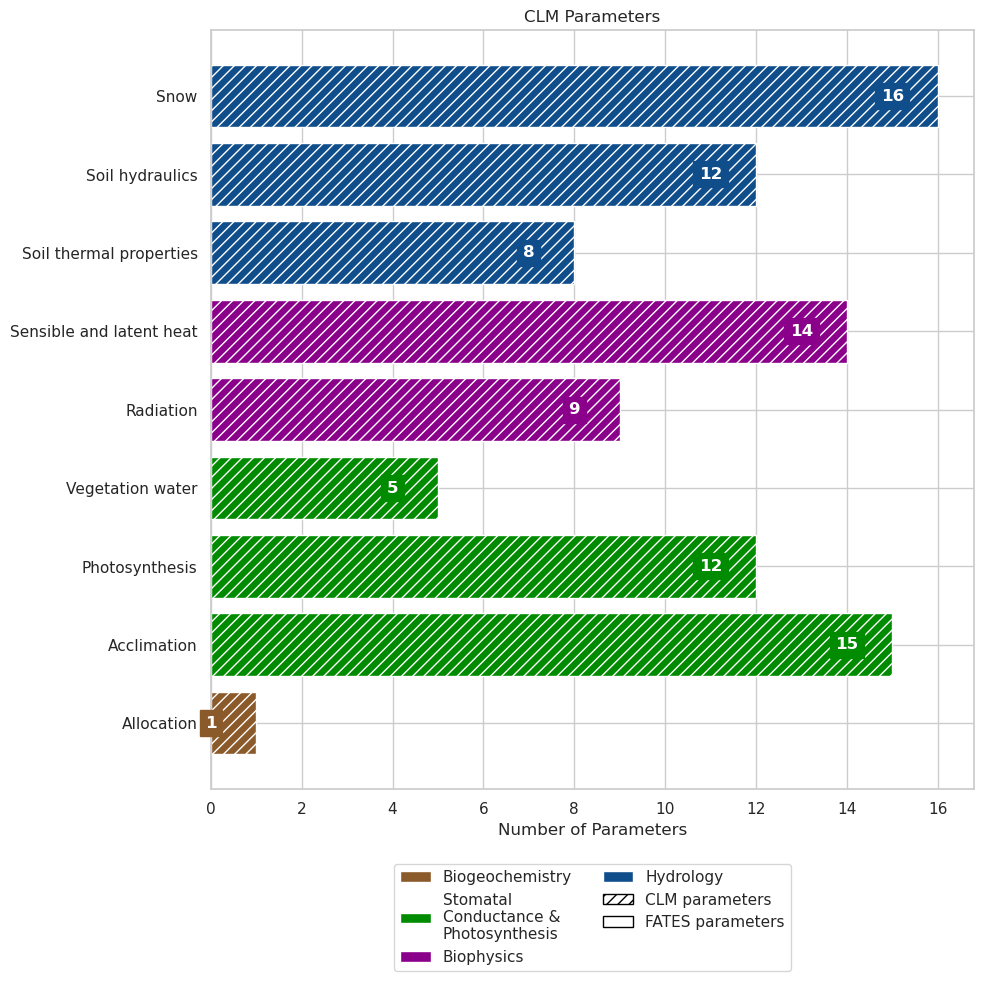

In [25]:
plotting.plot_oaat_params(clm_nonzero.drop_duplicates(), 'CLM')
plt.savefig(os.path.join(fig_dir, 'clm_oaat_parameters.png'))

In [27]:
clm_pars = np.unique(clmbtran_glob.where(clmbtran_glob.sum_diff > 0, drop=True).parameter_name.values)
fates_pars = np.unique(fates_glob_combo.where(fates_glob_combo.sum_diff > 0, drop=True).parameter_name.values)

In [28]:
variables = ['GPP', 'EF', 'ASA', 'SOILWATER_10CM']
variances = {}
for variable in variables:
    variances[variable] = {}
    
    clm_var = oaat.get_param_variance(clm_pars, variable, clmbtran_glob, 0)
    variances[variable]['CLM'] = oaat.get_cumulative_variance(clm_var, clm_pars, 5)

    fates_var = oaat.get_param_variance(fates_pars, variable, fates_glob_combo, 0)
    variances[variable]['FATES'] = oaat.get_cumulative_variance(fates_var, fates_pars, 5)

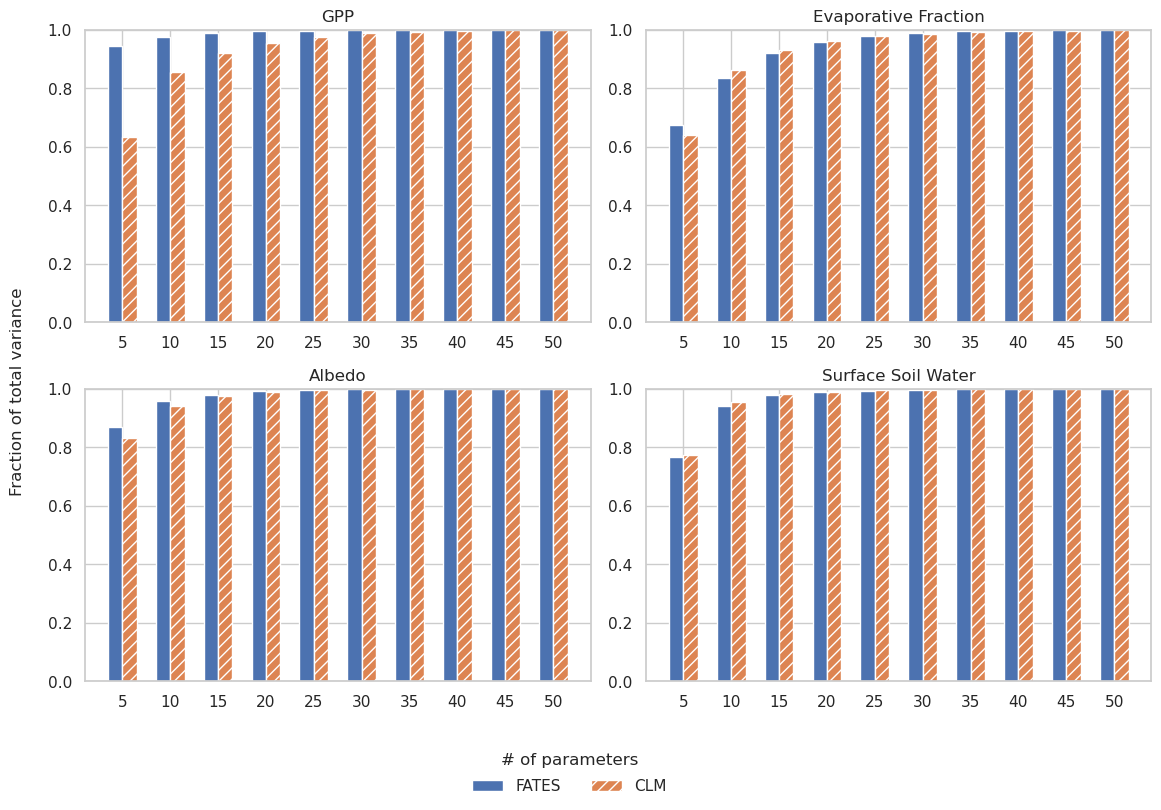

In [29]:
n_vars = len(variables)
ncols = 2
nrows = (n_vars + 1) // 2

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows), sharex=False)

for idx, variable in enumerate(variables):
    row = idx // ncols
    col = idx % ncols
    ax = axs[row, col] if nrows > 1 else axs[col]

    width = 1.5
    fates_cumvar = variances[variable]['FATES']
    clm_cumvar = variances[variable]['CLM']
    ax.bar(fates_cumvar.nparams[:10] - width/2, fates_cumvar[:10], width=width, label='FATES')
    ax.bar(clm_cumvar.nparams[:10] + width/2, clm_cumvar[:10], width=width, label='CLM', hatch='///')

    ax.set_ylim([0, 1])
    ax.set_xticks(clm_cumvar.nparams[:10])
    ax.set_title(var_dict[variable]['long_name'])

fig.text(0.5, 0.04, '# of parameters', ha='center', va='center', fontsize=12)
fig.text(0.04, 0.5, 'Fraction of total variance', ha='center', va='center',
         rotation='vertical', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False
)
plt.tight_layout(rect=[0.05, 0.08, 1, 1])
plt.savefig(os.path.join(fig_dir, 'variance_explained.png'))

In [30]:
# global
fates_meandiffs = oaat.get_min_max_diff(fates_combo_mean)
fates_meandiffs['parameter'] = fates_meandiffs.index
fates_meandiffs['model'] = 'FATES'

clm_meandiffs = oaat.get_min_max_diff(clmbtran_mean)
clm_meandiffs['parameter'] = clm_meandiffs.index
clm_meandiffs['model'] = 'CLM'

fatesclm_meandiffs_zero = fatesclm_meandiffs[fatesclm_meandiffs.index.isin(nonzero_params['fates_clm'])]
clm_meandiffs_zero = clm_meandiffs[clm_meandiffs.index.isin(nonzero_params['fates_clm'])]
both = pd.concat([clm_meandiffs_zero, fatesclm_meandiffs_zero])

NameError: name 'fatesclm_meandiffs' is not defined

In [71]:
exclude_list = np.append(nonzero_params['fates_clm'],
                         ['fates_leaf_vcmaxse',
                          'fates_leaf_vcmaxhd',
                          'fates_leaf_vcmaxha',
                          'fates_leaf_jmaxha',
                          'fates_leaf_jmaxse', 
                          'fates_leaf_jmaxhd',
                         'fates_rad_stem_rhovis',
                          'fates_rad_leaf_rhovis',
                          'fates_rad_leaf_taunir',
                          'fates_rad_leaf_tauvis',
                          'fates_rad_stem_rhonir',
                          'fates_rad_stem_taunir',
                          'fates_rad_stem_tauvis',
                         'fates_rad_leaf_taunir',
                         'fates_rad_leaf_rhonir'])

In [72]:
params = []
for variable in ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF']:
    fates_top10 = oaat.get_top_n(fates_combo_mean, fates_meandiffs, variable, 20,
                                exclude_list=exclude_list)
    params.append(fates_top10.parameter_name.values)
# plotting.plot_top_n(fates_top10, fates_combo_mean.sel(ensemble=0), variable,
#                     var_dict[variable]['long_name'],
#                     var_dict[variable]['global_units'], 70, 210)
# plt.savefig(os.path.join(fig_dir, f'{variable}_top10_FATES.png'))

In [73]:
top_params = sorted(np.unique(params))

In [ ]:
variable = 'GPP'
# clm_top10 = oaat.get_top_n(clmbtran_mean, clm_meandiffs, variable, 10)
plotting.plot_top_n(clm_top10, clmbtran_mean.sel(ensemble=0), variable,
                    var_dict[variable]['long_name'],
                    var_dict[variable]['global_units'], 70, 210)
plt.savefig(os.path.join(fig_dir, f'{variable}_top10_CLM.png'))

In [ ]:
biomes = fates_biome.biome.values
biome_diffs = []
for biome in biomes:
    df = oaat.get_min_max_diff(fates_biome.sel(summation_var='mean').sel(biome=biome))
    df['biome'] = biome
    biome_diffs.append(df)
biome_df = pd.concat(biome_diffs)

In [ ]:
variable = 'GPP'

top10s = []
for biome in biomes:
    fates_biome_mean = fates_biome.sel(summation_var='mean').sel(biome=biome)
    diff_df = biome_df[biome_df.biome == biome]
    top10 = oaat.get_top_n(fates_biome_mean, diff_df, variable, 10)
    top10['biome'] = biome
    top10s.append(top10)
all_top_10 = pd.concat(top10s)

In [ ]:
# plotting.plot_top_n(all_top_10, fates_biome.sel(summation_var='mean').sel(ensemble=0), variable,
#                     var_dict[variable]['long_name'],
#                     var_dict[variable]['global_units'], by_biomes=True)

In [ ]:
clm_reldiffs = oaat.get_vardiff(clmbtran_mean, clmbtran_mean.sel(ensemble=0),
                                variables, nonzero_params['clm_parameters'],
                                reldiff=True)
clm_reldiffs['model'] = 'CLM'
clm_reldiffs['parameter'] = clm_reldiffs.index

fatesclm_reldiffs = oaat.get_vardiff(fatesclm_mean, fatesclm_mean.sel(ensemble=0),
                                     variables, nonzero_params['fates_clm'],
                                     reldiff=True)
fatesclm_reldiffs['model'] = 'FATES'
fatesclm_reldiffs['parameter'] = fatesclm_reldiffs.index

fates_reldiffs = oaat.get_vardiff(fates_mean, fates_mean.sel(ensemble=0),
                                     variables, nonzero_params['fates_only'],
                                     reldiff=True)
fates_reldiffs['model'] = 'FATES'
fates_reldiffs['parameter'] = fates_reldiffs.index

clm_sub = clm_reldiffs[clm_reldiffs.index.isin(fatesclm_reldiffs.parameter)]
fates_clm_reldiff = pd.concat([clm_sub, fatesclm_reldiffs])

fates_reldiffs = pd.concat([fatesclm_reldiffs, fates_reldiffs])

In [ ]:
variable = 'EFLX_LH_TOT'
df = fates_clm_reldiff
df = df.sort_values(by=variable, ascending=False)

df = df[df[variable] > 0.1]
plt.figure(figsize=(7, 10))
sns.barplot(data=df, x=variable, y='parameter', hue='model')
plt.xlabel(f'Sensitivity Index ({variable})')
plt.ylabel('Parameter')
plt.legend(loc='lower right')
plt.tight_layout()

In [ ]:
df = clm_reldiffs[clm_reldiffs.index.isin(nonzero_params['clm_only'])]
variable = 'GPP'
df = df.sort_values(by=variable, ascending=False)

df = df[df[variable] > 0.1]
plt.figure(figsize=(7, 10))
sns.barplot(data=df, x=variable, y='parameter', hue='model')
plt.xlabel(f'Sensitivity Index ({variable})')
plt.ylabel('Parameter')
plt.legend(loc='lower right')
plt.tight_layout()

In [ ]:
df = fates_reldiffs[fates_reldiffs.index.isin(nonzero_params['fates_only'])]
variable = 'GPP'
df = df.sort_values(by=variable, ascending=False)

df = df[df[variable] > 0.1]
plt.figure(figsize=(7, 10))
sns.barplot(data=df, x=variable, y='parameter', hue='model')
plt.xlabel(f'Sensitivity Index ({variable})')
plt.ylabel('Parameter')
plt.legend(loc='lower right')
plt.tight_layout()

In [ ]:
for variable in variables:
    fates_top10 = oaat.get_top_n(fates_mean, fates_meandiffs, variable, 10)
    plotting.plot_top_n(fates_top10, fates_mean.sel(ensemble=0), variable,
                        var_dict[variable]['long_name'],
                        var_dict[variable]['global_units'])
    plt.savefig(os.path.join(fig_dir, f"FATES_area_means_top10_{variable}.png"))

### Climatology

In [ ]:
clim_fates = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_climatology.nc"))
clim_fates_ens = clim_fates.where(clim_fates.ensemble > fates['default'], drop=True)
clim_fates_ens = xr.merge([clim_fates_ens, fates_param_dat])

# clim_fates_clmpars = xr.open_dataset(os.path.join(hist_dir, f"{fates_clmp['name']}_climatology.nc"))
# clim_fates_clmpars_ens = clim_fates_clmpars.where(clim_fates_clmpars.ensemble > fates_clmp['default'], drop=True)
# clim_fates_clmpars_ens = xr.merge([clim_fates_clmpars_ens, clm_param_dat])

# clim_clm = xr.open_dataset(os.path.join(hist_dir, f"{clm_btran['name']}_climatology.nc"))
# clim_clm_ens = clim_clm.where(clim_clm.ensemble > clm_btran['default'], drop=True)
# clim_clm_ens = xr.merge([clim_clm_ens, clm_param_dat])

In [ ]:
fates_start, fates_end = oaat.get_ensemble_slopes(clim_fates_ens, fates_param_dat)
fates_start_diffs = oaat.get_min_max_diff(fates_start)
fates_end_diffs = oaat.get_min_max_diff(fates_end)

# fates_clmpars_start, fates_clmpars_end = oaat.get_ensemble_slopes(clim_fates_clmpars_ens, clm_param_dat)
# fates_clmpars_start_diffs = oaat.get_min_max_diff(fates_clmpars_start)
# fates_clmpars_end_diffs = oaat.get_min_max_diff(fates_clmpars_end)

# clm_start, clm_end = oaat.get_ensemble_slopes(clim_clm_ens, clm_param_dat)
# clm_start_diffs = oaat.get_min_max_diff(clm_start)
# clm_end_diffs = oaat.get_min_max_diff(clm_end)

In [ ]:
variable = 'GPP'
fates_top10 = oaat.get_top_n(fates_mean, fates_meandiffs, variable, 10)
ens_vals = fates_param_dat.where(fates_param_dat.parameter_name.isin(['fates_leaf_stomatal_slope_medlyn']), drop=True).ensemble.values
plotting.plot_oaat_climatology(clim_fates_ens, clim_fates.sel(ensemble=0), variable, var_dict[variable]['long_name'], 
                          var_dict[variable]['global_units'].replace('yr', 'month'), ens_vals)

### Zonal Means

In [ ]:
zonal_fates = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_zonal_means.nc"))
zonal_fates_ens = zonal_fates.where(zonal_fates.ensemble > fates['default'], drop=True)
zonal_fates_ens = xr.merge([zonal_fates_ens, fates_param_dat])

In [ ]:
variable = 'EFLX_LH_TOT'
plotting.plot_oaat_zonal(zonal_fates_ens, zonal_fates.sel(ensemble=0), variable,
                     var_dict[variable]['long_name'], var_dict[variable]['annual_units'])

### Maps

In [ ]:
exclude_list = ['fates_leaf_vcmaxse', 'fates_leaf_jmaxse',
                'fates_rad_leaf_taunir', 'fates_rad_stem_rhonir',
                'fates_rad_leaf_rhonir', 'fates_rad_stem_rhovis',
                'fates_rad_stem_taunir', 'fates_rad_leaf_rhovis',
                'rad_leaf_tauvis', 'fates_leaf_vcmaxhd',
               'fates_leaf_jmaxha', 'fates_leaf_jmaxhd',
               'fates_leaf_vcmaxha']
all_top10_params = []
for variable in ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF']:
    fates_top10 = oaat.get_top_n(fatesclm_mean, fatesclm_meandiffs, variable, 15,
                                 exclude_list=exclude_list)
    all_top10_params.append(fates_top10.parameter_name.values)
top_params = sorted(np.unique(all_top10_params))

In [ ]:
fates_maps = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_annual_maps.nc"))
fates_maps_ens = fates_maps.where(fates_maps.ensemble > fates['default'], drop=True)
fates_maps_ens = xr.merge([fates_maps_ens, fates_param_dat])

In [ ]:
clm_maps = xr.open_dataset(os.path.join(hist_dir, f"{clm_btran['name']}_annual_maps.nc"))
clm_maps_ens = clm_maps.where(clm_maps.ensemble > clm_btran['default'], drop=True)
clm_maps_ens = xr.merge([clm_maps_ens, clm_param_dat])

In [ ]:
dat = clm_maps_ens.where(clm_maps_ens.parameter_name == 'act25', drop=True)

In [ ]:
(dat.isel(ensemble=1).GPP - dat.isel(ensemble=0).GPP).plot()